<a href="https://colab.research.google.com/github/VaradRane12/fdip_lab/blob/Fa2/fdip_fa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

  Using cached ultralytics-8.3.209-py3-none-any.whl.metadata (37 kB)
  Using cached ultralytics_thop-2.0.17-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.w

In [ ]:
import requests
import zipfile
import os
import glob
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()
import shutil
import requests
import cv2
import numpy as np
import yaml
import os
import shutil
import zipfile
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

Ultralytics 8.3.209 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6519.7/8062.4 GB disk)


In [ ]:
def download_file(url, save_name):
    url = url
    if not os.path.exists(save_name):
        file = requests.get(url)
        open(save_name, 'wb').write(file.content)

In [ ]:
def unzip(zip_file=None):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")

In [ ]:
download_file(
    'https://www.dropbox.com/s/ievh0sesad015z0/trash_inst_material.zip?dl=1',
    'trash_inst_material.zip'
)

unzip(zip_file='trash_inst_material.zip')

Extracted all


In [ ]:
cwd = os.getcwd()
print(cwd)

/kaggle/working


In [ ]:
import yaml

attr = {
    'path': cwd+'/trash_inst_material',
    'train': 'train/images',
    'val': 'val/images',

    'names': {
        0: 'rov',
        1: 'plant',
        2: 'animal_fish',
        3: 'animal_starfish',
        4: 'animal_shells',
        5: 'animal_crab',
        6: 'animal_eel',
        7: 'animal_etc',
        8: 'trash_etc',
        9: 'trash_fabric',
        10: 'trash_fishing_gear',
        11: 'trash_metal',
        12: 'trash_paper',
        13: 'trash_plastic',
        14: 'trash_rubber',
        15: 'trash_wood',
    }
}

In [ ]:
with open('trashcan_inst_material.yaml', 'w') as f:
    yaml.dump(attr, f)

In [ ]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 82.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.

In [ ]:
EPOCHS = 10
!yolo \
task=detect \
mode=train \
model=yolov8m-seg.pt \
imgsz=640 \
data=trashcan_inst_material.yaml \
epochs={EPOCHS} \
batch=16 \
name=yolov8m-seg \
exist_ok=True \
amp=False

--- Visualizing Image Filters ---


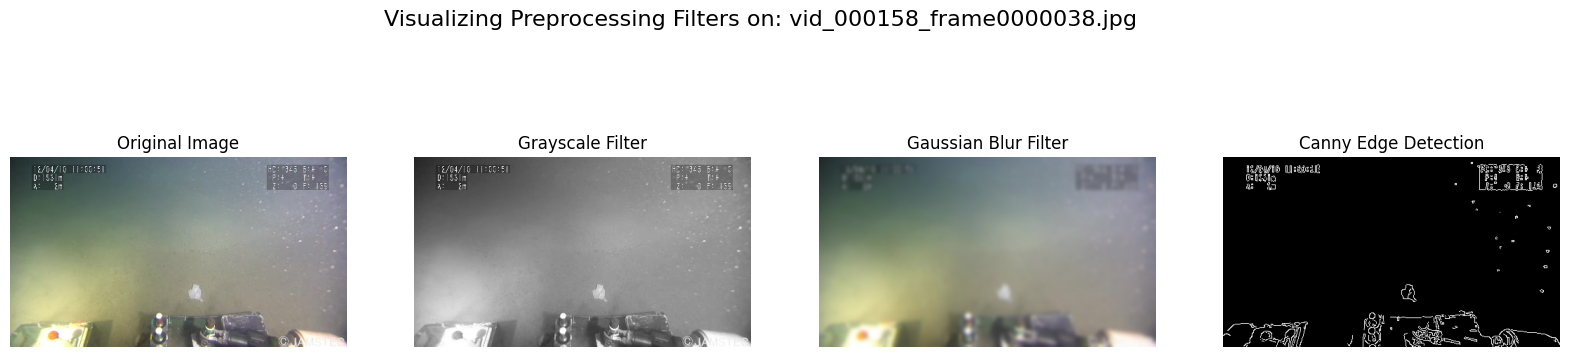


--- Creating Dataset for: Grayscale ---
Processing and saving grayscale images...
Copying labels...
Successfully created dataset and YAML file at 'trashcan_grayscale.yaml'
Ultralytics 8.3.209 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=trashcan_grayscale.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, 

In [ ]:
import os
import cv2
import shutil
import yaml
import random
import matplotlib.pyplot as plt

original_data_path = 'trash_inst_material'
processed_datasets_base_dir = 'processed_datasets'
original_images_dir = os.path.join(original_data_path, 'train', 'images')
original_labels_dir = os.path.join(original_data_path, 'train', 'labels')

print("--- Visualizing Image Filters ---")
sample_image_name = random.choice(os.listdir(original_images_dir))
sample_image_path = os.path.join(original_images_dir, sample_image_name)
original_image = cv2.imread(sample_image_path)
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
blur_image = cv2.GaussianBlur(original_image_rgb, (15, 15), 0)
canny_edges = cv2.Canny(original_image, 100, 200)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(original_image_rgb); axs[0].set_title('Original Image'); axs[0].axis('off')
axs[1].imshow(gray_image, cmap='gray'); axs[1].set_title('Grayscale Filter'); axs[1].axis('off')
axs[2].imshow(blur_image); axs[2].set_title('Gaussian Blur Filter'); axs[2].axis('off')
axs[3].imshow(canny_edges, cmap='gray'); axs[3].set_title('Canny Edge Detection'); axs[3].axis('off')
plt.suptitle(f'Visualizing Preprocessing Filters on: {sample_image_name}', fontsize=16)
plt.show()


def create_processed_dataset(processing_type, image_processor):
    print(f"\n--- Creating Dataset for: {processing_type.capitalize()} ---")

    dataset_dir = os.path.join(processed_datasets_base_dir, f"{processing_type}_dataset")
    train_dir = os.path.join(dataset_dir, 'train')
    new_images_dir = os.path.join(train_dir, 'images')
    new_labels_dir = os.path.join(train_dir, 'labels')

    os.makedirs(new_images_dir, exist_ok=True)
    os.makedirs(new_labels_dir, exist_ok=True)

    print(f"Processing and saving {processing_type} images...")
    for img_name in os.listdir(original_images_dir):
        img_path = os.path.join(original_images_dir, img_name)
        image = cv2.imread(img_path)
        if image is not None:
            processed_image = image_processor(image)
            cv2.imwrite(os.path.join(new_images_dir, img_name), processed_image)

    print(f"Copying labels...")
    for label_file in os.listdir(original_labels_dir):
        shutil.copy(os.path.join(original_labels_dir, label_file), new_labels_dir)

    with open('trashcan_inst_material.yaml', 'r') as f:
        data_yaml = yaml.safe_load(f)

    data_yaml['train'] = os.path.abspath(new_images_dir)
    data_yaml['val'] = os.path.abspath(os.path.join(original_data_path, 'val', 'images'))

    new_yaml_path = f'trashcan_{processing_type}.yaml'
    with open(new_yaml_path, 'w') as f:
        yaml.dump(data_yaml, f)

    print(f"Successfully created dataset and YAML file at '{new_yaml_path}'")
    return new_yaml_path

def apply_grayscale(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

def apply_blur(image):
    return cv2.GaussianBlur(image, (5, 5), 0)

def apply_canny(image):
    edges = cv2.Canny(image, 100, 200)
    return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

# --- 2. Create Datasets and Train Models ---
# Grayscale
grayscale_yaml = create_processed_dataset('grayscale', apply_grayscale)
!yolo task=segment mode=train model=yolov8n-seg.pt imgsz=640 data={grayscale_yaml} epochs=10 batch=16 name=yolov8n-seg_grayscale exist_ok=True amp=False

# Blur
blur_yaml = create_processed_dataset('blur', apply_blur)
!yolo task=segment mode=train model=yolov8n-seg.pt imgsz=640 data={blur_yaml} epochs=10 batch=16 name=yolov8n-seg_blur exist_ok=True amp=False

# Canny Edges
canny_yaml = create_processed_dataset('canny', apply_canny)
!yolo task=segment mode=train model=yolov8n-seg.pt imgsz=640 data={canny_yaml} epochs=10 batch=16 name=yolov8n-seg_canny exist_ok=True amp=False

print("\n--- All training sessions complete! ---")

In [ ]:
# Executing preprocessing step by step and showing intermediate images and stats
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

base_dir = "trash_inst_material/val

In [ ]:
basename = "vid_000140_frame0000021"
pattern = os.path.join(base_dir, basename + "*")
matches = glob.glob(pattern)

if len(matches) == 0:
    print(f"File not found with base name {basename} in {base_dir}")
    if os.path.exists(base_dir):
        files = sorted(os.listdir(base_dir))
        print(f"First 20 files in {base_dir}:")
        for f in files[:20]:
            print(f)
    else:
        print(f"Directory {base_dir} does not exist in this environment")
else:
    img_path = matches[0]
    print("Using file:", img_path)
    img = cv2.imread(img_path)
    if img is None:
        print("cv2.imread returned None. The file may be corrupted or unreadable.")
    else:
        # 1 Original
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title("Original image")
        plt.show()

        # 2 Convert to LAB and show L channel
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        plt.figure(figsize=(6,5))
        plt.imshow(l)
        plt.axis("off")
        plt.title("L channel (LAB) before CLAHE")
        plt.show()

        # 3 Histogram of L channel
        plt.figure(figsize=(7,3))
        plt.hist(l.ravel(), bins=256)
        plt.title("Histogram of L channel")
        plt.show()

        # 4 Apply CLAHE to L channel and show result
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        plt.figure(figsize=(6,5))
        plt.imshow(cl)
        plt.axis("off")
        plt.title("L channel after CLAHE")
        plt.show()

                # 3 Histogram of L channel
        plt.figure(figsize=(7,3))
        plt.hist(cl.ravel(), bins=256)
        plt.title("Histogram of L channel")
        plt.show()

        # 5 Reconstruct LAB with CLAHE L and convert back to BGR
        limg = cv2.merge((cl, a, b))
        enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
        enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(enhanced_rgb)
        plt.axis("off")
        plt.title("Image after CLAHE (converted back to BGR)")
        plt.show()

        # 6 White balance statistics before adjustment
        b_ch, g_ch, r_ch = cv2.split(enhanced)
        r_avg = float(np.mean(r_ch))
        g_avg = float(np.mean(g_ch))
        b_avg = float(np.mean(b_ch))
        k = (r_avg + g_avg + b_avg) / 3.0
        # compute scaling factors
        r_scale = (k / r_avg) if r_avg > 0 else 1.0
        g_scale = (k / g_avg) if g_avg > 0 else 1.0
        b_scale = (k / b_avg) if b_avg > 0 else 1.0

        print("Channel averages before white balance")
        print(f"r_avg {r_avg:.2f}, g_avg {g_avg:.2f}, b_avg {b_avg:.2f}")
        print("Scaling factors to be applied")
        print(f"r_scale {r_scale:.4f}, g_scale {g_scale:.4f}, b_scale {b_scale:.4f}")

        # 7 Apply per channel scaling for white balance

        r_adj = np.clip(r_ch.astype(np.float32) * r_scale, 0, 255).astype(np.uint8)
        g_adj = np.clip(g_ch.astype(np.float32) * g_scale, 0, 255).astype(np.uint8)
        b_adj = np.clip(b_ch.astype(np.float32) * b_scale, 0, 255).astype(np.uint8)
        final = cv2.merge([b_adj, g_adj, r_adj])
        final_rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(final_rgb)
        plt.axis("off")
        plt.title("Final image after white balance")
        plt.show()

        # 8 Absolute difference between pre and post white balance to highlight changes
        diff = cv2.absdiff(enhanced, final)
        diff_rgb = cv2.cvtColor(diff, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,6))
        plt.imshow(diff_rgb)
        plt.axis("off")
        plt.title("Absolute difference between pre and post white balance")
        plt.show()

In [ ]:
# --- 1. PREPROCESSING FUNCTION ---
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # White Balance (Gray World)
    b_ch, g_ch, r_ch = cv2.split(enhanced_img)
    r_avg = cv2.mean(r_ch)[0]
    g_avg = cv2.mean(g_ch)[0]
    b_avg = cv2.mean(b_ch)[0]
    k = (r_avg + g_avg + b_avg) / 3
    r_ch = cv2.addWeighted(r_ch, k / r_avg, 0, 0, 0)
    g_ch = cv2.addWeighted(g_ch, k / g_avg, 0, 0, 0)
    b_ch = cv2.addWeighted(b_ch, k / b_avg, 0, 0, 0)
    final_img = cv2.merge([b_ch, g_ch, r_ch])


    return final_img

In [ ]:
# --- 2. SCRIPT TO CREATE & PROCESS THE DATASET ---
original_data_root = 'trash_inst_material/'
processed_data_root = 'trash_inst_material_processed/'

if not os.path.exists(processed_data_root):
    os.makedirs(processed_data_root)

for split in ['train', 'val']:
    original_img_dir = os.path.join(original_data_root, split, 'images')
    processed_img_dir = os.path.join(processed_data_root, split, 'images')
    original_label_dir = os.path.join(original_data_root, split, 'labels')
    processed_label_dir = os.path.join(processed_data_root, split, 'labels')

    os.makedirs(processed_img_dir, exist_ok=True)
    os.makedirs(processed_label_dir, exist_ok=True)

    image_files = os.listdir(original_img_dir)

    print(f"Processing and copying {split} files...")
    for filename in tqdm(image_files):
        # Process and save images
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_path = os.path.join(original_img_dir, filename)
            output_path = os.path.join(processed_img_dir, filename)
            processed_image_data = preprocess_image(input_path)
            cv2.imwrite(output_path, processed_image_data)

    # Copy label files
    for filename in os.listdir(original_label_dir):
        shutil.copy(os.path.join(original_label_dir, filename), processed_label_dir)

print("\nPreprocessing and file copying complete!")

In [ ]:
# --- 3. VISUALIZATION OF RESULTS ---
print("Displaying comparison of original vs. preprocessed images...")

# Get a random sample of images to display
val_images_dir = os.path.join(original_data_root, 'val', 'images')
sample_images = random.sample(os.listdir(val_images_dir), 4) # Display 4 images

plt.figure(figsize=(20, 10))

for i, img_name in enumerate(sample_images):
    # Path to original image
    original_path = os.path.join(val_images_dir, img_name)

    # Path to processed image
    processed_path = os.path.join(processed_data_root, 'val', 'images', img_name)

    # Read images
    original_img = cv2.imread(original_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    processed_img = cv2.imread(processed_path)
    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)

    # Display Original
    plt.subplot(2, 4, i + 1)
    plt.imshow(original_img_rgb)
    plt.title(f"Original: {img_name}")
    plt.axis('off')

    # Display Processed
    plt.subplot(2, 4, i + 5)
    plt.imshow(processed_img_rgb)
    plt.title(f"Processed: {img_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# --- 3. CREATE YAML CONFIGURATION FILE ---
print("\nCreating data.yaml file...")

# Define the dataset attributes
# The 'path' is the absolute path to your processed dataset folder
data_yaml = {
    'path': os.path.abspath(processed_data_root),
    'train': 'train/images',
    'val': 'val/images',

    'names': {
        0: 'rov',
        1: 'plant',
        2: 'animal_fish',
        3: 'animal_starfish',
        4: 'animal_shells',
        5: 'animal_crab',
        6: 'animal_eel',
        7: 'animal_etc',
        8: 'trash_etc',
        9: 'trash_fabric',
        10: 'trash_fishing_gear',
        11: 'trash_metal',
        12: 'trash_paper',
        13: 'trash_plastic',
        14: 'trash_rubber',
        15: 'trash_wood',
    }
}

# Write the dictionary to a YAML file
yaml_path = os.path.join(processed_data_root, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"YAML file saved to: {yaml_path}")

In [ ]:
# --- 4. VISUALIZATION OF RESULTS ---
print("\nDisplaying comparison of original vs. preprocessed images...")

# Get a random sample of images to display
val_images_dir = os.path.join(original_data_root, 'val', 'images')
sample_images = random.sample(os.listdir(val_images_dir), min(4, len(os.listdir(val_images_dir)))) # Display 4 or fewer images

if sample_images:
    plt.figure(figsize=(20, 10))

    for i, img_name in enumerate(sample_images):
        # Path to original image
        original_path = os.path.join(val_images_dir, img_name)

        # Path to processed image
        processed_path = os.path.join(processed_data_root, 'val', 'images', img_name)

        # Read images
        original_img = cv2.imread(original_path)
        original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

        processed_img = cv2.imread(processed_path)
        processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)

        # Display Original
        plt.subplot(2, 4, i + 1)
        plt.imshow(original_img_rgb)
        plt.title(f"Original: {img_name}")
        plt.axis('off')

        # Display Processed
        plt.subplot(2, 4, i + 5)
        plt.imshow(processed_img_rgb)
        plt.title(f"Processed: {img_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images found in the validation directory to display.")

In [ ]:
!pip install "numpy<2"

In [ ]:
# Define the number of epochs for training
# 5 is very few for good results, consider starting with 25-50
EPOCHS = 5

# Run the YOLOv8 segmentation training command
!yolo \
task=segment \
mode=train \
model=yolov8m-seg.pt \
imgsz=640 \
data=trash_inst_material_processed/data.yaml \
epochs={EPOCHS} \
batch=8 \
name=yolov8m_marine_debris_seg \
exist_ok=True \
amp=False